> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 LAB 7: DATA TRANSFORMATION**

## Outline

- Load and preview the cleaned Megatelco dataset  
- Engineer new columns from existing data  
- Binning to simplify numeric variable values  
- One-hot-Encoding and integer encoding to change categorical into numeric values
- Use log transformation, min-max normalization and z-score standardization
- Try your own transformation logic  

This lab continues from **Lab 6**, where we cleaned the Megatelco dataset.  

Now, we will create new, more useful features for modeling and exploration.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

If you're new to Colab: [Colab FAQ](https://research.google.com/colaboratory/faq.html)




## Megatelco Data Dictionary

 DEMOGRAPHIC VARIABLES:
 - College - has the customer attended some college (one, zero)
 - Income - annual income of customer
 - House - estimated price of the customer's home (if applicable)

 USAGE VARIABLES:
 - Data Overage Mb - Average number of megabytes that the customer used in excess of the plan limit (over last 12 months)
 - Data Leftover Mb - Average number of megabytes that the customer use was below the plan limit (over last 12 months)
 - Data Mb Used - Average number of megabytes used per month (over last 12 months)
 - Text Message Count - Average number of texts per month (over last 12 months)
 - Over 15 Minute Calls Per Month - Average number of calls over 15 minutes in duration per month (over last 12 months)
 - Average Call Duration- Average call duration (over last 12 months)

PHONE VARIABLES:
 - Operating System - Current operating system of phone
 - Handset Price - Retail price of the phone used by the customer

ATTITUDINAL VARIABLES:
 - Reported Satisfaction - Survey response to "How satisfied are you with your current phone plan?" (high, avg, low)
 - Reported Usage Level - Survey response to "How much do your use your phone?" (high, avg, low)
 - Considering Change of Plan - Survey response to "Are you currently planning to change companies when your contract expires?" (no, yes)

OTHER VARIABLES
 - Leave - Did this customer churn with the last contract expiration? (LEAVE, STAY, Unknown)
 - ID - Customer identifier

## **Part 1: Load Cleaned Data from Lab 6 and Preview it**

In this part of the lab, we will load the cleaned data from Lab 6. We had previously completed the following cleaning steps.

- Cleaned column names
- Fixed data types
- Handled missing values
- Removed duplicate records
- Reviewed for outliers

The link to the cleaned data is provided for your below. It contains 14,200 rows instead of 15,016 that we started out with in Lab 6.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/megatelco_cleaned.csv"
df = pd.read_csv(url)

df.sample(n=5)

,id,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,operating_system
9253,8500,one,356441.0,208,46.0,3812.0,57,539360,458.0,5.0,5.0,low,low,yes,STAY,Android
2487,3581,one,306700.0,175,73.0,6225.0,68,923372,1300.0,4.0,2.0,low,high,no,LEAVE,IOS
12272,7871,zero,66157.0,287,28.0,3582.0,102,704442,442.0,19.0,5.0,low,low,yes,LEAVE,Android
7899,16938,one,257799.0,181,7.0,1523.0,155,701778,1315.0,22.0,12.0,low,low,yes,LEAVE,IOS
3840,10101,one,376702.0,0,20.0,3163.0,192,1032960,1260.0,1.0,5.0,low,high,yes,STAY,IOS


In [12]:
#check datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14200 entries, 0 to 14199
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           14200 non-null  int64  
 1   college                      14200 non-null  object 
 2   income                       14200 non-null  float64
 3   data_overage_mb              14200 non-null  int64  
 4   data_leftover_mb             14200 non-null  float64
 5   data_mb_used                 14200 non-null  float64
 6   text_message_count           14200 non-null  int64  
 7   house                        14200 non-null  int64  
 8   handset_price                14200 non-null  float64
 9   over_15mins_calls_per_month  14200 non-null  float64
 10  average_call_duration        14200 non-null  float64
 11  reported_satisfaction        14200 non-null  object 
 12  reported_usage_level         14200 non-null  object 
 13  considering_chan

The only cleaning step we have to redo again is fixing data types. When we read in data, it once again infers data types.

In [13]:
# Check original data types
print("Original dtypes:\n", df.dtypes)

# Convert object to nomimal categorical - can use df[colname].astype() to convert to nominal categorical
obj_to_nomcat_cols = ['considering_change_of_plan', 'college', 'operating_system', 'leave']
for acol in obj_to_nomcat_cols:
    df[acol] = df[acol].astype('category')

# Convert object/text columns with limited possible values with an order to ordinal categorical columnns
obj_to_ordcat_cols = ['reported_satisfaction', 'reported_usage_level']
for acol in obj_to_ordcat_cols:
    df[acol] = pd.Categorical(df[acol], categories = ['low', 'avg', 'high'], ordered = True)

# Check updated data types
print("\nUpdated dtypes:\n", df.dtypes)



Original dtypes:
 id                               int64
college                         object
income                         float64
data_overage_mb                  int64
data_leftover_mb               float64
data_mb_used                   float64
text_message_count               int64
house                            int64
handset_price                  float64
over_15mins_calls_per_month    float64
average_call_duration          float64
reported_satisfaction           object
reported_usage_level            object
considering_change_of_plan      object
leave                           object
operating_system                object
dtype: object

Updated dtypes:
 id                                int64
college                        category
income                          float64
data_overage_mb                   int64
data_leftover_mb                float64
data_mb_used                    float64
text_message_count                int64
house                             int64
handse

In [14]:
# View missing value counts
print("Missing values per column:\n", df.isnull().sum())

# Check for exact duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Missing values per column:
 id                             0
college                        0
income                         0
data_overage_mb                0
data_leftover_mb               0
data_mb_used                   0
text_message_count             0
house                          0
handset_price                  0
over_15mins_calls_per_month    0
average_call_duration          0
reported_satisfaction          0
reported_usage_level           0
considering_change_of_plan     0
leave                          0
operating_system               0
dtype: int64

Number of duplicate rows: 0


## **Part 2: Data Transformation**

***Data cleaning** makes the data more **usable**. **Data transformation** makes the data more **useful for ML***

After cleaning, the major next step is data transformation, getting data ready for predictive modeling and **feature engineering** — creating new columns from data to better capture useful patterns, and make it more ***useful***, meaningful and ready for Machine Learning.

In this and the next few sections, we will learn the following common techniques for creating new meaningful features:

1. **Creating new features** using builtin functions and algebra (+ - / *), that make patterns in the data more meaningful to ML models

2. **Binning** or discretizing continuous numeric variables using `pd.cut()` or `pd.qcut()` — to group them into bins (quantiles)

3. **Scaling** variables
  - to reduce extreme values (esp. positive skew) in data using ***log-transformation*** (`np.log()`),
  - to make things be of similar/same scale using ***standardization*** (`StandardScaler`) and ***normalization*** (`MinMaxScaler`).

4. **Encoding** categorical variables
  - nominal categorical variables (with no order in values) with **one-hot-encoding** also known as **dummy coding** using `pd.get_dummies()`. e.g., colors
  - ordinal catgeorical variables (e.g., satisfaction levels such as low, medium, high), we use **integer encoding** also known as **label encoding**. An easy way is to use `df.map()` that maps each value to an integer that we provide.


These new features help ML  models learn better, and thus makes these models more powerful (more predictive power), and may make results easier to interpret.

Things to think about:
- What are some new combinations (e.g., ratios, additions) of the existing columns that might be useful and meaningful to predict whether a customer would leave or stay?
- Can you create flag variables (a binary 0/1 variable) to highlight important traits (such as high data user, big texter etc) that you suspect might have interesting correlations with the target ?


In [15]:
# Create a total data available variable (used + leftover)
df['total_data_mb'] = df['data_mb_used'] + df['data_leftover_mb']

# Create a ratio of overage to used data
df['overage_ratio'] = df['data_overage_mb'] / (df['data_mb_used'] + 1)  # add 1 to avoid divide-by-zero

# Create a binary flag for high texters (over 135 texts which is the mean)
df['high_texter'] = (df['text_message_count'] > 135).astype(int)

# Preview new columns
df[['total_data_mb', 'overage_ratio', 'high_texter']].head()


,total_data_mb,overage_ratio,high_texter
0,6605.0,0.010596,1
1,6044.0,0.011113,0
2,1482.0,0.040459,1
3,3027.0,0.000000,1
4,1794.0,0.000000,0


### 🔧 **Try It Yourself  Part 2**

2.1. Create a variable called `call_volume` by multiplying `over_15mins_calls_per_month` by `average_call_duration`

2.2. Create a binary flag `high_data_user` for users where `data_mb_used` is above the median

2.3. Use `.sample(n)` to check a random sample of 10 rows of your new columns' values



In [ ]:
# 🔧 2.1. Add code here


# 🔧 2.2. Add code here


# 🔧 2.3. Add code here



## **Part 3: Binning Continous Variables**

Binning is the process of grouping numeric variables into categories (e.g., "low", "avg", "high").

### Why We Bin:
- Helps reduce the impact of outliers
- Allows us to use numeric values in models that prefer categories
- Simplifies interpretation and visualization

### Things to think about:
- Would binning values make patterns more visible?
- Do we want equal-sized groups or logical cutoffs?
- Is the variable skewed?

**Tools:**  
- `pd.qcut()` for quantile-based bins (equal frequency = same number of observations in each bin)  
- `pd.cut()` for equal-width bins (bins are of the same width) or custom size bins


In [16]:
# Bin income into 3 equal obervation groups (quantiles): low, medium, high
df['income_group'] = pd.qcut(df['income'], q=3, labels=['low', 'medium', 'high'])

# Bin average call duration into 4 equal-width bins using pd.cut(), labels = False will use 0,1,2,3
df['call_duration_group'] = pd.cut(df['average_call_duration'], bins=4, labels=False)

# Preview new groupings
df[['income', 'income_group', 'average_call_duration', 'call_duration_group']].sample(n=10)

,income,income_group,average_call_duration,call_duration_group
11920,331191.0,high,6.0,1
1187,356976.0,high,4.0,0
3109,319573.0,high,5.0,0
4921,185535.0,medium,17.0,3
5618,334119.0,high,2.0,0
12263,196283.0,medium,6.0,1
1464,208726.0,medium,4.0,0
1265,361132.0,high,2.0,0
6083,332602.0,high,6.0,1
375,91077.0,low,2.0,0


### 🔧 **Try It Yourself - Part 3**

3.1. Use `pd.cut()` to group `data_mb_used` into 3 labeled bins: "light", "moderate", "heavy"

3.2. Use `pd.qcut()` on `text_message_count` to split into 4 equal-sized groups with integer labels

3.3. Print `.value_counts()` on each new column to see how values are distributed.

> Reminder: To ensure multiple outputs show, use `print()` or `display()` or write code in separate cells.



In [ ]:
# 🔧 3.1. Add code here


# 🔧 3.2. Add code here


# 🔧 3.3. Add code here


## **Part 4: Scaling Numeric Variables**

Scaling transforms values to a common range (often 0–1), which helps many machine learning models perform better.

### When to Scale:
- When features have very different ranges (e.g., income vs. call duration)
- When using distance-based models (e.g., KNN, SVM)
    - they use distance between observations to make decisions, and having variables of different units can distort results
- When comparing magnitudes across features (variables or columns)

### Common Methods:
- **Log scaling**: takes log of the column values; changes the shape of the distribution to make it *more normal*, reduces large extreme values, and expands small values
- **MinMaxScaler**: scales to 0-1 range; does NOT change the shape of the distribution, only rescales them, most sensitive to outlierd.
- **StandardScaler**: centers data around mean = 0 with unit variance (var = 1); also does NOT change the shape of the distribtion, only rescales them

### What scaling to use?
Generally speaking,

- if there are positive outliers in a variable (positive skew), first **log transform** using `np.log()`. Log scaling will try to make the shape more normal, removing skew/outliers.

- for continuous numeric data that do not have heavy outliers, use either standardization (**StandardScaler**) or normalization (**MinMaxScaler**)

- DO NOT scale binary and one-hot encoded variable columns (0/1). Leave them be.

### Things to think about:
- Are any features skewed to the right?
  - use histograms to check.
  The histogram for handset_price shows that it's skewed to the right. This means there are a few very expensive handsets, but most are in a lower price range. Log scaling can help.
- Which features are on very different scales?
- Does the ML algorithm (that you plan to use in the Modeling phase) care about magnitude or distance?


**Tools:** `np.log()`, `MinMaxScaler`, `StandardScaler`

### Plot some histograms

Let us begin by plotting our original numeric variables to see their distributions. This will give us a clue as to what transformation to use.

- Anything that is skewed, let us log scale first.
- Then standardize continuous vars


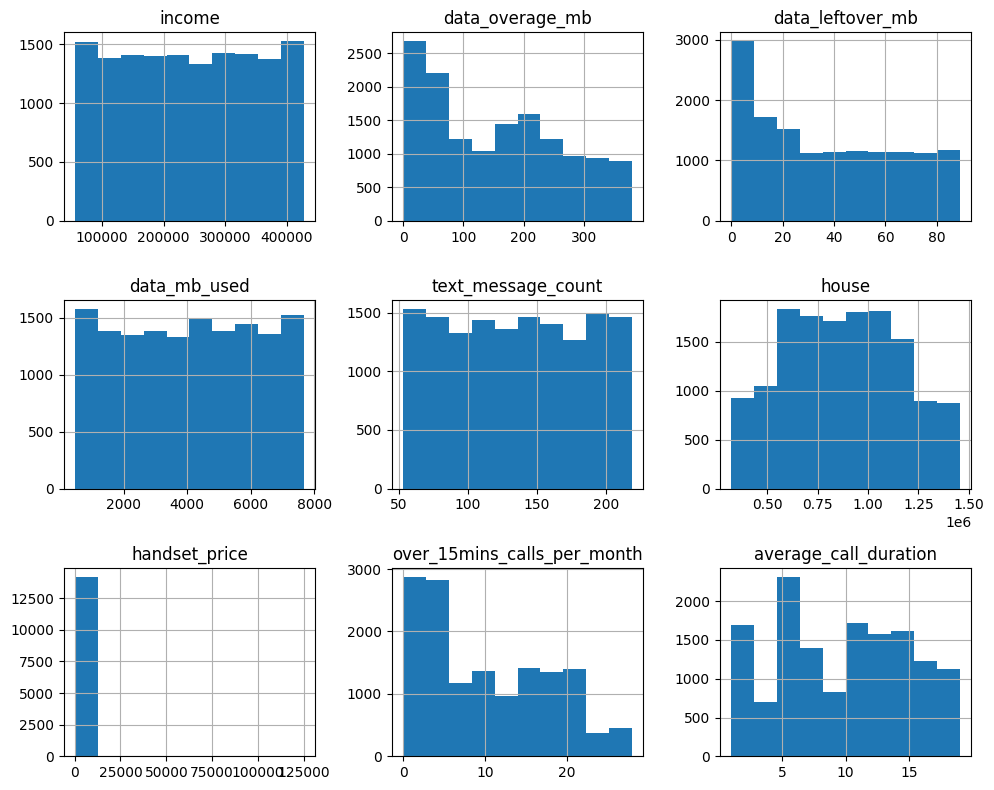

In [17]:
cols_to_plot = ['income', 'data_overage_mb', 	'data_leftover_mb', 	'data_mb_used', 	'text_message_count', 	'house', 	'handset_price', 	'over_15mins_calls_per_month', 	'average_call_duration']

plt.figure(figsize=(10, 8)) # Figure height: (x, y)
for i, col in enumerate(cols_to_plot):
    plt.subplot(3, 3, i + 1) # plot a grid of 3 by 3 with 9 subplots
    df[col].hist()
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
# MinMaxScaler and StandardScaler are classes that need to be imported so we can use them
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# log scaling of right-skewed handset_price - add 1 to ensure log exists
df['logprice']= np.log(df['handset_price'] + 1)

# Initialize MinMaxScaler and StandardScaler
# we will only use StandardScaler here
stdscaler = StandardScaler()
mmscaler = MinMaxScaler()

# create a list of cols to standardize and apply StandardScaler
# creates a new df with only 3 cols
cols_to_std = ['income', 'data_mb_used', 'house']
df_std = stdscaler.fit_transform(df[cols_to_std])

# Add standardized columns back to df
df['income_std'] = df_std[:, 0]
df['data_mb_used_std'] = df_std[:, 1]
df['house_std'] = df_std[:, 2]

# Preview
df[['logprice', 'income_std', 'data_mb_used_std', 'house_std']].head()

,logprice,income_std,data_mb_used_std,house_std
0,6.483107,1.472335,1.194328,-0.123768
1,7.085064,-1.025876,0.922219,-1.395322
2,6.945051,-1.573682,-1.221640,-0.232187
3,7.057898,1.238765,-0.503405,-0.173807
4,6.931472,1.279951,-1.074503,0.261823


### **🔧 Try It Yourself - Part 4**

4.1. Scale `over_15mins_calls_per_month` using log scaling and add the new  column back to df with a prefix "log". Add a 1 to the values before taking log, because log 0 does not exist, or you will get -inf values.

4.2. Scale `average_call_duration` using StandardScaler and add the new  column back to df with suffix "_std"

4.3. Scale `text_message_count` using `MinMaxScaler` and add the new  column back to df with suffix "_norm".

4.4. Use `.describe()` to compare original vs. scaled versions and make a comment on what you observe


In [ ]:
# 🔧 4.1. Add code here


# 🔧 4.2. Add code here


# 🔧 4.3. Add code here


# 🔧 4.4. Add code here



🔧 4.4 Make a comment on what you observe in your comparison

### ✍️ Your Response: 🔧
4.4



## **Part 5: Encoding Categorical Variables**

Most machine learning models can't handle string categories directly (and can only use numeric values) —so we convert them into numbers using **encoding**.

### Types of Encoding:
- **One-hot encoding**: creates a binary column for each unique value in the original categorical column (**used for nominal categorical variables**)
  - an example: We have a column called Colors with 3 values: red, blue, green - that we want to treat as nominal. OHE will create 3 new columns corresponidng to each color, and place a 1 in the new column, wherever the value in original column matches the color in its colname.
  - The original column is ***dropped*** by default, so it adds n new colums where n = number of unique values, and drops 1

|Color   |   red  | blue  | green  |
|--------|--------|-------|--------|
|red     |    1   |   0   |    0   |
|blue    |    0   |   1   |    0   |
|green   |    0   |   0   |    1   |
|red     |    1   |   0   |    0   |

- **Ordinal/integer/label encoding**: assigns integers (**use only for ordered categories**)
  - An example: if we have a column called Education, we may want to set their values as 1,2,3,.....
  - adds only one new column, original column remains.

|Education   | educ_int  |
|--------|--------|
|some high school |     1     |
|high school grad |     2    |
|some college  |     3     |
|college grad |     4    |

### Things to consider:
- Is the variable nominal (e.g., OS type) or ordinal (e.g., satisfaction)?
- How many unique categories are there?
- Will one-hot encoding make the dataset too wide?
    - yes, this technique is good for less than 10 or so categories. If there are too many values, we may just keep it as string. Instead of manual one-hot encoding, newer ML frameworks have built-in, native solutions for categorical string data.

**Tools:**
  - `df.map()` for integer encoding.
  - `pd.get_dummies()` for nominal encoding,

In [19]:
# Ordinal/ integer encode 'reported_usage_level'
df['usagelvl_encode'] = df['reported_usage_level'].map({'low': 1, 'avg': 2, 'high': 3})

# One-hot encode 'income_group' if we consider it nominal - income_group will get dropped to avoid redundancy
df_encoded = pd.get_dummies(df, columns =['income_group'], prefix='income')

df = df_encoded.copy()

# Preview new columns
print(df.filter(like='usage').sample(n=10))
print(df.filter(like='income').sample(n=10))


      reported_usage_level usagelvl_encode
8353                   low               1
7959                   low               1
13371                  low               1
4198                   low               1
3919                  high               3
13836                  low               1
1055                   low               1
236                   high               3
2664                  high               3
6395                   low               1
          income  income_std  income_low  income_medium  income_high
8117   292970.00    0.465813       False           True        False
11063   95538.00   -1.337992        True          False        False
1347   235494.00   -0.059307       False           True        False
10409  144166.00   -0.893710        True          False        False
2170    91740.00   -1.372691        True          False        False
9218   348302.00    0.971344       False          False         True
5212   322956.00    0.739775       False    

### 🔧 **Try It Yourself - Part 5**

5.1. Choose and write code to correctly encode: `operating_system` and `reported_satisfaction`.

5.2. Print `.shape` of your dataframe df before and after to observe changes



In [ ]:
# 🔧 5.1. Add code here


# 🔧 5.2. Add code here




🔧 5.3. How many new columns were added in 5.1? explain. read the text cell above to understand.

### ✍️ Your Response: 🔧
5.3

# **Part 6: Reflection (100 words or less per question)**

### 🔧 **Answer overall reflection questions - Part 6**

6.1. Which transformation do you think had the biggest impact on preparing your data for modeling?

6.2. Are there any features you created that you think will be especially useful for predicting churn (leave (or stay))?

🔧 6.1. Add comment here:



🔧 6.2. Add comment here:

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_07_LastnameFirstname.ipynb"